In [38]:
import nltk
import json
import pandas as pd
import numpy as np
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from storage.database import Database

In [24]:
DATABASE_PATH = "../data.db"
QUANTITY = 10000
database = Database(DATABASE_PATH)

try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')
nltk.download('rslp')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\micael.conti\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [4]:
def mostrar_tabela(x,vec,title):
    df_bow = pd.DataFrame(x.toarray(), columns=vec.get_feature_names_out())
    print(title)
    display(df_bow)

In [25]:
def get_corpus(documentos, campo):
    corpus = [
        json.loads(d[campo])
        for d in documentos
        if campo in d and d[campo]
    ] 
     
    return corpus  

In [27]:
def processar_dados_bow(campo, size):
    discursos = database.get_discursos(size)
    corpus = get_corpus(discursos, campo)
    
    bow_vec = CountVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_bow = bow_vec.fit_transform(corpus)
    
    return X_bow, bow_vec,corpus

In [28]:
def processar_dados_td_idf(campo,size):
    discursos = database.get_discursos(size)
    corpus = get_corpus(discursos, campo)
    
    tfidf_vec = TfidfVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_tfidf = tfidf_vec.fit_transform(corpus)
    
    return X_tfidf, tfidf_vec, corpus

In [9]:
def search_and_rank(query, vectorizer, X_corpus, corpus, method_name):
    """
    Vetoriza uma query, calcula a similaridade com o corpus e exibe os resultados.
    """
    q_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(q_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1]

    print(f"Top-3 Similares para a Query (usando {method_name}):")
    for i in rank[:3]:
        if sim_scores[i] > 0.01: # Apenas mostra se houver alguma similaridade
            print(f"  Doc{i+1} (score={sim_scores[i]:.3f}): {corpus[i]}")
    print("-" * 40)

In [32]:
def matriz_similaridade_top_n(dados,top_n):
    print("Calculando a matriz de similaridade de cossenos...")

    sim_matrix = cosine_similarity(dados, dados)

    sim_no_diag = sim_matrix.copy()
    np.fill_diagonal(sim_no_diag, 0)

    mean_sim = sim_no_diag.mean(axis=1)
    top_idxs = np.argsort(mean_sim)[::-1][:top_n]

    sub_sim = sim_matrix[np.ix_(top_idxs, top_idxs)]
    doc_labels = [f"Doc{i+1}" for i in top_idxs]

    df_similarity = pd.DataFrame(sub_sim, index=doc_labels, columns=doc_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_similarity, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Heatmap dos {top_n} documentos mais semelhantes")
    plt.xlabel("Documentos")
    plt.ylabel("Documentos")
    plt.tight_layout()
    plt.show()

In [40]:
def grafico2D(dados):
    pca = PCA(n_components=2)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    plt.figure(figsize=(10, 7))
    plt.scatter(X_tfidf_pca[:, 0], X_tfidf_pca[:, 1], c='blue', alpha=0.7, s=100)
    plt.title("Visualização 2D dos Vetores de Documentos")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.grid(True)

    plt.show()

In [43]:
def grafico3D(dados):
    pca = PCA(n_components=3)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        X_tfidf_pca[:, 0],
        X_tfidf_pca[:, 1],
        X_tfidf_pca[:, 2],
        alpha=0.7,
        s=100
    )

    ax.set_title("Visualização 3D dos Vetores de Documentos")
    ax.set_xlabel("Componente Principal 1")
    ax.set_ylabel("Componente Principal 2")
    ax.set_zlabel("Componente Principal 3")
    ax.grid(True)
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()

In [45]:
x_bow_stem, bow_vec_stem, bow_corpus_stem = processar_dados_bow("transcricao_stemizado", QUANTITY)

mostrar_tabela(x_bow_stem,bow_vec_stem,"Matriz Documento-Termo (BoW):")

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Matriz Documento-Termo (BoW):


,aa,aaa,aagd,aahmsnpvoqltgxmwqhxayhuogwymsawumwkealpawgyovwmehehx,aaktzkyq,aapdp,aara,aba,abacat,abacax,...,zulian,zumb,zumbiland,zunzunzum,zur,zurab,zwgxf,zxkj,zyon,zyrhfq
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9834,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9835,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
x_tf_idf_token,vec_tf_idf_token,corpus_tf_idf_token = processar_dados_td_idf("transcricao_tokens", QUANTITY)
x_tf_idf_stem,vec_tf_idf_stem,corpus_tf_idf_stem = processar_dados_td_idf("transcricao_stemizado", QUANTITY)
x_tf_idf_lem,vec_tf_idf_lem,corpus_tf_idf_lem = processar_dados_td_idf("transcricao_lemizado", QUANTITY)

mostrar_tabela(x_tf_idf_token,vec_tf_idf_token,"Matriz Documento-Termo (TF-IDF)")

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Matriz Documento-Termo (TF-IDF)


,aa,aaa,aagd,aahmsnpvoqltgxmwqhxayhuogwymsawumwkealpawgyovwmehehxe,aaktzkyq,aapdp,aarao,abacateiro,abacaxi,abacc,...,zuliani,zumbi,zumbilandia,zunzunzum,zur,zurab,zwgxf,zxkj,zyon,zyrhfqo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
query = "educacao publica investimento escolas professores"

print(f">> Executando busca para a query: '{query}'\n")

search_and_rank(query, bow_vec_stem, x_bow_stem, bow_corpus_stem, "BoW")
search_and_rank(query, vec_tf_idf_token, x_tf_idf_token, corpus_tf_idf_token, "TF-IDF")

>> Executando busca para a query: 'educacao publica investimento escolas professores'

Top-3 Similares para a Query (usando BoW):
  Doc2191 (score=0.303): ['discurs', 'integr', 'encaminh', 'sra', 'deput', 'luiziann', 'lim', 'registr', 'taquigraf', 'pktcontenttypesxml', 'ej', 'uzqjzecjzhfkpxagrk', 'albdjgc', 'u', 'doagecjseerjbypbbriefosvqsfiyvaavnex', 'hvquopw', 'szcgxtl', 'ulbjjg', 'bsenuavaojovvgpnnzjsfgnmc', 'apd', 'cjellspxsf', 'sbxztfcrtsulmgkbpihiwoyeooxnwsbwdfplnqsgwgwnnxrgryvepg', 'kfqcmtncwowksbysaqwy', 'vnqnu', 'yziucnrtnbzehqlofbqqqcfxtseep', 'zlhbmbk', 'mflfwyatiwgglsmfdqym', 'wc', 'xvdfvyyvy', 'xkxzaudlqruvscpytjuundutssay', 'dgqmagfqdgrd', 'kghnf', 'hebxt', 'xeyihobvlan', 'iwyandhv', 'ahdjyx', 's', 'ykduccphbc', 'mvyicøcdoefhczz', 'irdmfgedcya', 'ckglp', 'dovbcfkpvgajftv', 'pnkgdmunahpifhcelfvynn', 'm', 'c', 'znfdpegmqp', 'vkigytlisv', 'tfiwmigpp', 'dlvxb', 'qjexmcz', 'b', 'atfsnt', 'iyairkd', 'yiz', 'jtt', 'fq', 'g', 'zex', 'csx', 'thqsffh', 'yt', 'xkfrskktkbpu', 'vmyskq

Calculando a matriz de similaridade de cossenos...


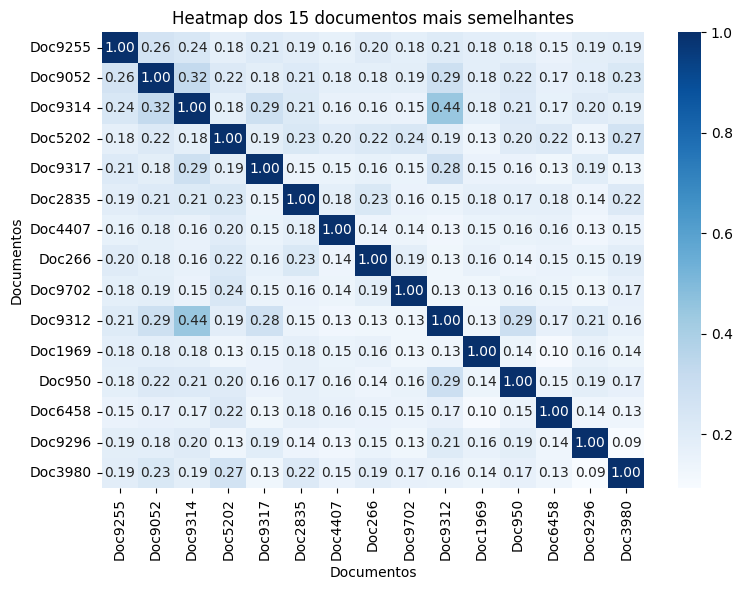

In [48]:
matriz_similaridade_top_n(x_tf_idf_token,15)

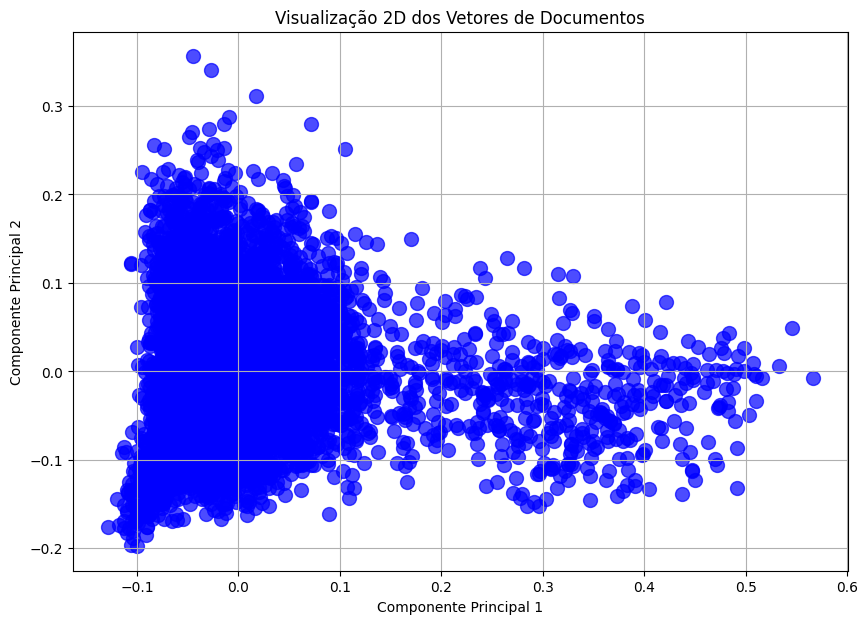

In [49]:
grafico2D(x_tf_idf_token)

In [ ]:
grafico3D(x_tf_idf_token)